# m10b — Siamese Calibration Branch (From Scratch)

**Same architecture as m10a** (GazeNetM5 + CalCNN branch) but trained
entirely from scratch — no m5c backbone weight transfer.

**Rationale:** If m10a (transfer) shows the cal_cnn embeddings are near-zero,
it means the transferred backbone ignores the calibration signal. Training
from scratch lets all branches co-adapt from epoch 1.

**Hyperparams:** Match m5c exactly (lr=1e-4, wd=5e-4, batch=32, patience=6,
sqrt inv freq class weights, label smoothing=0.1).

**Key decisions (same as m10a):**
- cal_cnn is independent (no weight sharing with face_cnn)
- Calibration image is NOT augmented during training
- CEAL eval uses 0V_0H images as calibration
- Cal bank reused from m10a (already saved to Drive)

In [1]:
# ============================================================
# INSTALL
# ============================================================
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.8 MB/s eta 0:00:00


In [3]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# ============================================================
# IMPORT
# ============================================================
import os, glob, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')
print(f'Device: {device}')

True
NVIDIA A100-SXM4-80GB
Device: cuda


In [5]:
# ============================================================
# ALL PATHS
# ============================================================

DRIVE_ROOT      = Path('/content/drive/MyDrive/210/')
TAR_DIR         = '/content/gaze_wds_balanced'
LABELS_CSV      = DRIVE_ROOT / 'gaze_labels.csv'
GEO_PARQUET     = DRIVE_ROOT / 'geo_features_v1.parquet'
CAL_BANK_PATH   = DRIVE_ROOT / 'calibration_bank_v1.pt'

MODEL_NAME      = 'm10b'
CKPT_DIR        = DRIVE_ROOT / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = CKPT_DIR / f'{MODEL_NAME}_best.pth'

print(f'TAR_DIR:      {TAR_DIR}')
print(f'LABELS_CSV:   {LABELS_CSV}')
print(f'GEO_PARQUET:  {GEO_PARQUET}')
print(f'CAL_BANK:     {CAL_BANK_PATH}')
print(f'CHECKPOINT:   {CHECKPOINT_PATH}')

TAR_DIR:      /content/gaze_wds_balanced
LABELS_CSV:   /content/drive/MyDrive/210/gaze_labels.csv
GEO_PARQUET:  /content/drive/MyDrive/210/geo_features_v1.parquet
CAL_BANK:     /content/drive/MyDrive/210/calibration_bank_v1.pt
CHECKPOINT:   /content/drive/MyDrive/210/checkpoints/m10b_best.pth


In [6]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'{TAR_DIR}/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files_src = sorted(glob.glob(source + '*.tar'))
    for f in tar_files_src:
        fname = os.path.basename(f)
        dest = f'{local_dir}/{fname}'
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f'{split}: {count} tars copied')

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [7]:
# ============================================================
# VERIFY FILES
# ============================================================

train_tar_urls = sorted(glob.glob(f'{TAR_DIR}/train/*.tar'))
val_tar_urls   = sorted(glob.glob(f'{TAR_DIR}/val/*.tar'))
test_tar_urls  = sorted(glob.glob(f'{TAR_DIR}/test/*.tar'))

print(f'Train tars: {len(train_tar_urls)}')
print(f'Val tars:   {len(val_tar_urls)}')
print(f'Test tars:  {len(test_tar_urls)}')
print(f'Labels CSV: {os.path.exists(LABELS_CSV)}')
print(f'Geo parquet: {os.path.exists(GEO_PARQUET)}')
print(f'Cal bank:   {os.path.exists(CAL_BANK_PATH)}')

Train tars: 75
Val tars:   16
Test tars:  16
Labels CSV: True
Geo parquet: True
Cal bank:   True


In [8]:
# ============================================================
# LOAD LABELS (4-class, drop Straight)
# ============================================================

df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f'Loaded {len(df_labels)} labeled frames')

label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}

label_lookup_4 = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    if row['label'] != 'Straight':
        label_lookup_4[key] = row['label']

print(f'4-class label lookup: {len(label_lookup_4)} entries')

Loaded 849131 labeled frames
4-class label lookup: 602467 entries


In [9]:
# ============================================================
# LOAD GEO FEATURES
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f'Loaded geo features: {len(df_geo)} rows')

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['key']] = row[geo_cols].values.astype(np.float32)

GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

# Coverage check
matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
print(f'Geo coverage: {matched}/{len(label_lookup_4)} ({100*matched/len(label_lookup_4):.1f}%)')

Loaded geo features: 273462 rows
Geo coverage: 192519/602467 (32.0%)


In [10]:
# ============================================================
# IMAGE TRANSFORMS (same as m5c)
# Cal face: Normalize only, NO augmentation.
# ============================================================

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

cal_normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

print('Transforms defined')

Transforms defined


In [11]:
# ============================================================
# CalCNN — calibration face encoder
# Small independent CNN: [B, 3, 224, 224] -> [B, 128]
# ============================================================

class CalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),   # -> [32, 112, 112]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # -> [64, 56, 56]
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # -> [128, 28, 28]
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                # -> [128, 1, 1]
        )
        self.fc = nn.Linear(128, 128)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

print(f'CalCNN params: {sum(p.numel() for p in CalCNN().parameters()):,}')

CalCNN params: 111,296


In [12]:
# ============================================================
# GazeNetM10 — GazeNetM5 architecture + CalCNN branch
# FC input: 4608 + 4608 + 2304 + 64 + 128 = 11712
# ============================================================

class GazeNetM10(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super().__init__()

        # ---- Eye CNN (shared L/R) ----
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Face CNN ----
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # ---- Geo MLP ----
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # ---- Calibration branch ----
        self.cal_cnn = CalCNN()

        # ---- FC classifier ----
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64 + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features, cal_face):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        cal_feat   = self.cal_cnn(cal_face)

        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat, cal_feat], dim=1)
        return self.fc(combined)

print('GazeNetM10 defined')
_test = GazeNetM10(num_classes=4)
print(f'  Parameters: {sum(p.numel() for p in _test.parameters()):,}')
del _test

GazeNetM10 defined
  Parameters: 6,763,652


In [13]:
# ============================================================
# CAL BANK INJECTOR
# ============================================================

def make_cal_injector(cal_bank_path):
    bank = torch.load(cal_bank_path, map_location='cpu')
    print(f'Loaded cal bank: {len(bank)} subjects')

    def inject(sample):
        sid = sample['json']['subject_id']
        if sid in bank:
            sample['cal_face'] = bank[sid]
        else:
            print(f'WARNING: no cal image for subject {sid}')
            sample['cal_face'] = torch.zeros(3, 224, 224)
        return sample

    return inject

cal_injector = make_cal_injector(CAL_BANK_PATH)

Loaded cal bank: 640 subjects


In [14]:
# ============================================================
# DATASET PIPELINE (same as m10a)
# ============================================================

def make_dataset_m10(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample['__key__']

        # Skip Straight
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample['face.jpg'])
        left_eye = np.array(sample['left.jpg'])
        right_eye = np.array(sample['right.jpg'])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        cal_face = cal_normalize(sample['cal_face'])

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'cal_face': cal_face,
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode('pil')
        .map(cal_injector)
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print('make_dataset_m10 defined')

make_dataset_m10 defined


In [15]:
# ============================================================
# MODEL SETUP — from scratch, no pretrained weights
# Same hyperparams as m5c
# ============================================================

train_dataset = make_dataset_m10(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_m10(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_m10(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

# ---- Model from scratch ----
model = GazeNetM10(num_classes=4).to(device)

# ---- Class weights (sqrt inv freq, same as m5c) ----
train_counts = [4247, 51514, 42872, 40888]  # Up, Down, Left, Right
total = sum(train_counts)
weights = [math.sqrt(total / (4 * c)) for c in train_counts]
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights (sqrt inv freq):')
for name, w in zip(['Up', 'Down', 'Left', 'Right'], weights):
    print(f'  {name:6s}: {w:.3f}')

criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f'\nModel: {MODEL_NAME} (from scratch)')
print(f'Device: {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Class weights (sqrt inv freq):
  Up    : 2.866
  Down  : 0.823
  Left  : 0.902
  Right : 0.924

Model: m10b (from scratch)
Device: cuda
Parameters: 6,763,652


In [16]:
# ============================================================
# SMOKE TEST
# ============================================================

test_tar = [train_tar_urls[0]]
print(f'Testing with: {test_tar[0]}')

test_ds = make_dataset_m10(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

batch = next(iter(smoke_loader))

print(f'\nBatch contents:')
print(f"  left_eye:     {batch['left_eye'].shape}")
print(f"  right_eye:    {batch['right_eye'].shape}")
print(f"  face:         {batch['face'].shape}")
print(f"  geo_features: {batch['geo_features'].shape}")
print(f"  cal_face:     {batch['cal_face'].shape}")
print(f"  label:        {batch['label'].tolist()}  (should be 0-3)")

model.eval()
with torch.no_grad():
    out = model(
        batch['left_eye'].to(device),
        batch['right_eye'].to(device),
        batch['face'].to(device),
        batch['geo_features'].to(device),
        batch['cal_face'].to(device),
    )
print(f'\nOutput: {out.shape}  <-- should be [4, 4]')
print('Pipeline works end-to-end!')

Testing with: /content/gaze_wds_balanced/train/gaze-train-000000.tar

Batch contents:
  left_eye:     torch.Size([4, 3, 48, 48])
  right_eye:    torch.Size([4, 3, 48, 48])
  face:         torch.Size([4, 3, 112, 112])
  geo_features: torch.Size([4, 7])
  cal_face:     torch.Size([4, 3, 224, 224])
  label:        [1, 1, 1, 1]  (should be 0-3)

Output: torch.Size([4, 4])  <-- should be [4, 4]
Pipeline works end-to-end!


In [17]:
# ============================================================
# m10b TRAINING LOOP — from scratch, same structure as m5c
# ============================================================

num_epochs = 20
best_val_loss = float('inf')
patience = 6
patience_counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f"{'='*50}")

    # ---- TRAIN ----
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        cal_face     = batch['cal_face'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features, cal_face)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            eta_min = (elapsed / (batch_idx + 1)) * (7000 - batch_idx - 1) / 60
            print(f'  Batch {batch_idx+1}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_min:.1f} min')

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ---- VAL ----
    model.eval()
    val_loss, val_correct, val_total, val_batch_count = 0.0, 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            cal_face     = batch['cal_face'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features, cal_face)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f'  Train loss: {avg_train_loss:.4f}  acc: {train_acc:.2f}%')
    print(f'  Val   loss: {avg_val_loss:.4f}  acc: {val_acc:.2f}%  ({epoch_time:.0f}s)')

    # ---- Early stopping + checkpoint ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), str(CHECKPOINT_PATH))
        print(f'  -> New best val loss: {avg_val_loss:.4f}, saved.')
    else:
        patience_counter += 1
        print(f'  -> No improvement ({patience_counter}/{patience})')
        if patience_counter >= patience:
            print('Early stopping triggered.')
            break

torch.save(model.state_dict(), str(CKPT_DIR / f'{MODEL_NAME}_final.pth'))
print(f'\nDone. Best val loss: {best_val_loss:.4f}')


Epoch 1/20
  Batch 1000/~7000 - Loss: 0.9731 - ETA: 14.5 min
  Batch 2000/~7000 - Loss: 0.6638 - ETA: 12.2 min
  Batch 3000/~7000 - Loss: 0.6744 - ETA: 9.5 min
  Batch 4000/~7000 - Loss: 0.6303 - ETA: 7.0 min
  Train loss: 0.8129  acc: 84.38%
  Val   loss: 0.7089  acc: 89.82%  (621s)
  -> New best val loss: 0.7089, saved.

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.4873 - ETA: 14.6 min
  Batch 2000/~7000 - Loss: 0.6539 - ETA: 12.2 min
  Batch 3000/~7000 - Loss: 0.6138 - ETA: 9.5 min
  Batch 4000/~7000 - Loss: 0.5671 - ETA: 6.9 min
  Train loss: 0.6528  acc: 93.12%
  Val   loss: 0.6763  acc: 91.08%  (619s)
  -> New best val loss: 0.6763, saved.

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.6453 - ETA: 14.5 min
  Batch 2000/~7000 - Loss: 0.6495 - ETA: 12.2 min
  Batch 3000/~7000 - Loss: 0.8145 - ETA: 9.5 min
  Batch 4000/~7000 - Loss: 0.5222 - ETA: 7.0 min
  Train loss: 0.6127  acc: 94.90%
  Val   loss: 0.6749  acc: 91.30%  (620s)
  -> New best val loss: 0.6749, saved.

Epoch 4/20
  Batch 1000/

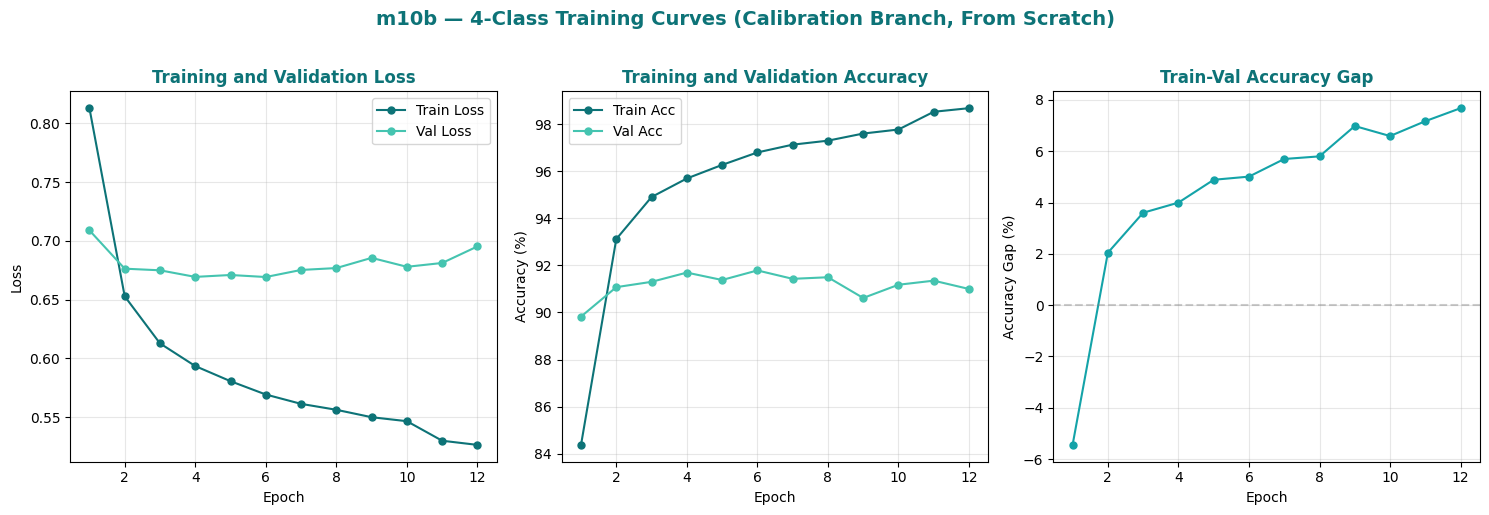


Training Summary
Total epochs completed: 12
Best validation loss: 0.6692 (Epoch 6)
Best validation accuracy: 91.79% (Epoch 6)
Final train accuracy: 98.68%
Final val accuracy: 91.00%
Final train-val gap: 7.68%


In [18]:
# ============================================================
# LOSS CURVES — Teal theme
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss ----
ax = axes[0]
ax.plot(range(1, len(train_losses) + 1), train_losses, '-o', color=teal_dark, label='Train Loss', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_light, label='Val Loss', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy ----
ax = axes[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies, '-o', color=teal_dark, label='Train Acc', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_light, label='Val Acc', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap ----
ax = axes[2]
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(gap) + 1), gap, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — 4-Class Training Curves (Calibration Branch, From Scratch)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Summary ----
print("\n" + "="*50)
print("Training Summary")
print("="*50)
print(f"Total epochs completed: {len(train_losses)}")
print(f"Best validation loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best validation accuracy: {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final train accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final val accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final train-val gap: {train_accuracies[-1] - val_accuracies[-1]:.2f}%")
print("="*50)


In [19]:
# ============================================================
# DIAGNOSTIC: cal_cnn embedding magnitude vs other branches
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()
batch = next(iter(val_loader))

with torch.no_grad():
    left_feat  = model.eye_cnn(batch['left_eye'].to(device)).view(batch['left_eye'].size(0), -1)
    right_feat = model.eye_cnn(batch['right_eye'].to(device)).view(batch['right_eye'].size(0), -1)
    face_feat  = model.face_cnn(batch['face'].to(device)).view(batch['face'].size(0), -1)
    geo_feat   = model.geo_mlp(batch['geo_features'].to(device))
    cal_feat   = model.cal_cnn(batch['cal_face'].to(device))

print(f'left_eye  mean abs: {left_feat.abs().mean():.4f}')
print(f'right_eye mean abs: {right_feat.abs().mean():.4f}')
print(f'face      mean abs: {face_feat.abs().mean():.4f}')
print(f'geo       mean abs: {geo_feat.abs().mean():.4f}')
print(f'cal_cnn   mean abs: {cal_feat.abs().mean():.4f}')

left_eye  mean abs: 0.0167
right_eye mean abs: 0.0189
face      mean abs: 0.0347
geo       mean abs: 0.0387
cal_cnn   mean abs: 0.0058


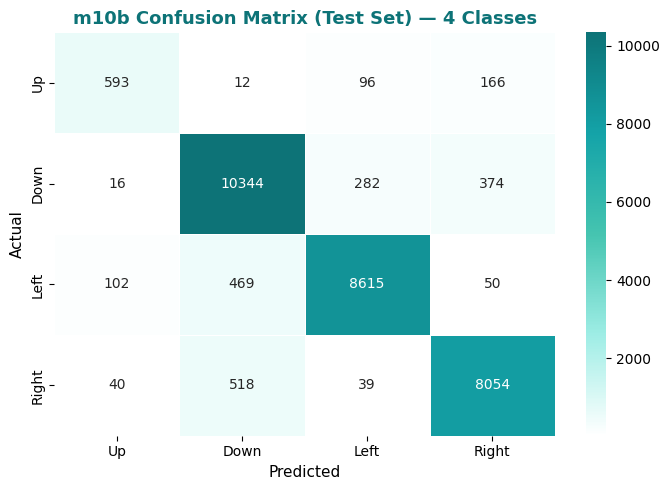


m10b Test Set Performance
              precision    recall  f1-score   support

          Up       0.79      0.68      0.73       867
        Down       0.91      0.94      0.93     11016
        Left       0.95      0.93      0.94      9236
       Right       0.93      0.93      0.93      8651

    accuracy                           0.93     29770
   macro avg       0.90      0.87      0.88     29770
weighted avg       0.93      0.93      0.93     29770



In [20]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        cal_face     = batch['cal_face'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features, cal_face)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

teal_cmap = LinearSegmentedColormap.from_list('teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set) — 4 Classes',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print(f'{MODEL_NAME} Test Set Performance')
print('='*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

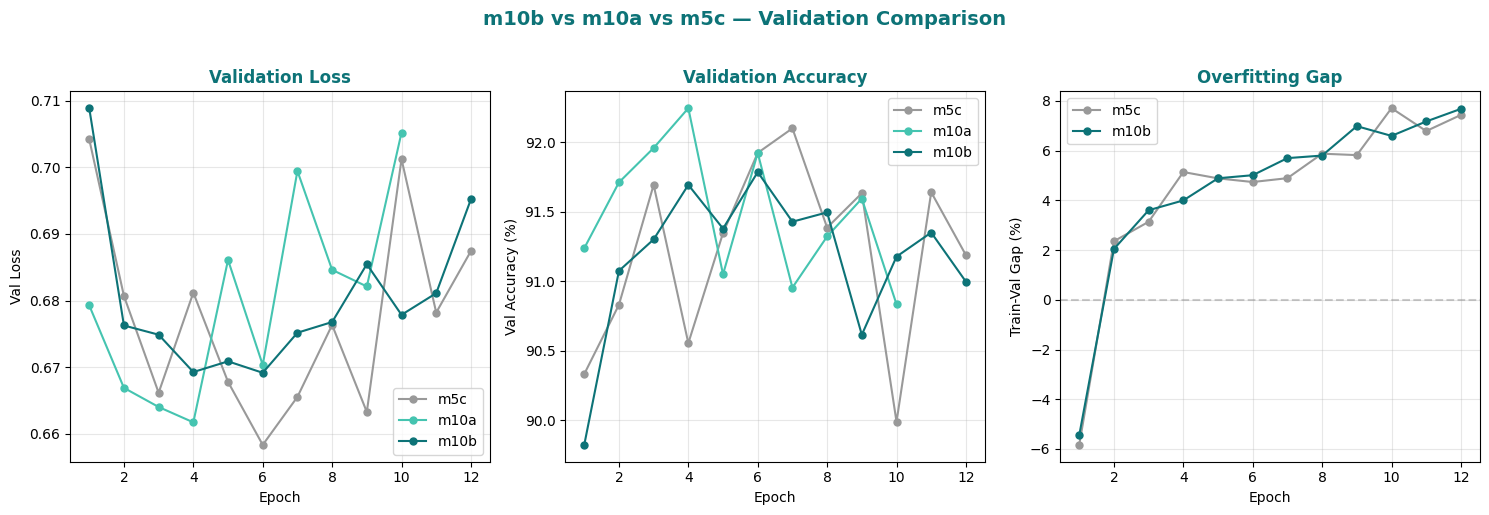


m10b vs m10a vs m5c
m5c  best val loss: 0.6583  best val acc: 92.10%
m10a best val loss: 0.6617  best val acc: 92.25%
m10b best val loss: 0.6692  best val acc: 91.79%

m10b vs m5c  — loss: +0.0108  acc: -0.31%
m10b vs m10a — loss: +0.0074  acc: -0.46%


In [21]:
# ============================================================
# COMPARE m10b vs m10a vs m5c
# ============================================================

# m5c results
m5c_train_losses = [0.8119657339100662, 0.6533410661511945, 0.6146887101402143, 0.5943828028253229, 0.5817236840260245, 0.5719863340631042, 0.5644072491117804, 0.5586943424259186, 0.553295024031484, 0.5484996645159744, 0.5326650714866067, 0.5283544815357495]
m5c_val_losses = [0.7042028013595754, 0.6806879599047246, 0.6661611421296826, 0.6811815809563728, 0.6677970519173617, 0.6583361093270577, 0.6655390130597992, 0.6763349390636056, 0.6632756286590112, 0.7012312029041139, 0.6781952198952604, 0.6874267592605224]
m5c_train_acc = [84.49552397130181, 93.18740548017861, 94.83231914908866, 95.69598841751422, 96.23282516610402, 96.66215121737946, 96.99400090308986, 97.2649278603221, 97.45486342557751, 97.6992710774722, 98.42962708122792, 98.62601328832218]
m5c_val_acc = [90.33307404002545, 90.83162435471324, 91.69436390637155, 90.55583056360936, 91.34785375857436, 91.92419206562478, 92.10098295735804, 91.38674775475567, 91.63425500318223, 89.99009971006294, 91.64132663885157, 91.18874195601443]

# !!! PASTE m10a results here after m10a finishes !!!
m10a_val_losses = [0.6792692237991398, 0.6668925494460737, 0.6640255322900869, 0.6617191399894865, 0.6860962034618787, 0.6703337310397692, 0.6994470614497944, 0.6846080337877327, 0.6821129482344719, 0.7052052397512447]
m10a_val_acc = [91.23824340569973, 91.71204299554486, 91.95955024397144, 92.24595148857931, 91.05084506046248, 91.92419206562478, 90.95537797892652, 91.3231030337317, 91.59536100700092, 90.83516017254792]
m10a_train_losses = [0.5967730145557187, 0.5644707844238767, 0.554700308725173, 0.5495802186697728, 0.5442178661438938, 0.5415567368972851, 0.5377831525743568, 0.5360195495357374, 0.5216707316827567, 0.5194318605259289]
m10a_train_acc = [95.60782964571642, 96.9703485496807, 97.31223256714043, 97.61039556769232, 97.84978605371235, 97.9630306548835, 98.12429670085507, 98.25402627561442, 98.90195741142911, 98.9721977336745]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---- Loss comparison ----
ax = axes[0]
ax.plot(range(1, len(m5c_val_losses) + 1), m5c_val_losses, '-o', color='#999999', label='m5c', markersize=5)
if m10a_val_losses:
    ax.plot(range(1, len(m10a_val_losses) + 1), m10a_val_losses, '-o', color=teal_light, label='m10a', markersize=5)
ax.plot(range(1, len(val_losses) + 1), val_losses, '-o', color=teal_dark, label='m10b', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_title('Validation Loss', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Accuracy comparison ----
ax = axes[1]
ax.plot(range(1, len(m5c_val_acc) + 1), m5c_val_acc, '-o', color='#999999', label='m5c', markersize=5)
if m10a_val_acc:
    ax.plot(range(1, len(m10a_val_acc) + 1), m10a_val_acc, '-o', color=teal_light, label='m10a', markersize=5)
ax.plot(range(1, len(val_accuracies) + 1), val_accuracies, '-o', color=teal_dark, label='m10b', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy (%)')
ax.set_title('Validation Accuracy', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

# ---- Overfitting gap comparison ----
ax = axes[2]
m5c_gap = [m5c_train_acc[i] - m5c_val_acc[i] for i in range(len(m5c_train_acc))]
m10b_gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(range(1, len(m5c_gap) + 1), m5c_gap, '-o', color='#999999', label='m5c', markersize=5)
ax.plot(range(1, len(m10b_gap) + 1), m10b_gap, '-o', color=teal_dark, label='m10b', markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train-Val Gap (%)')
ax.set_title('Overfitting Gap', fontweight='bold', color=teal_dark)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('m10b vs m10a vs m5c — Validation Comparison',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

# ---- Delta summary ----
print("\n" + "="*50)
print("m10b vs m10a vs m5c")
print("="*50)
print(f"m5c  best val loss: {min(m5c_val_losses):.4f}  best val acc: {max(m5c_val_acc):.2f}%")
if m10a_val_losses:
    print(f"m10a best val loss: {min(m10a_val_losses):.4f}  best val acc: {max(m10a_val_acc):.2f}%")
print(f"m10b best val loss: {min(val_losses):.4f}  best val acc: {max(val_accuracies):.2f}%")
print()
print(f"m10b vs m5c  — loss: {min(val_losses) - min(m5c_val_losses):+.4f}  acc: {max(val_accuracies) - max(m5c_val_acc):+.2f}%")
if m10a_val_acc:
    print(f"m10b vs m10a — loss: {min(val_losses) - min(m10a_val_losses):+.4f}  acc: {max(val_accuracies) - max(m10a_val_acc):+.2f}%")
print("="*50)

In [22]:
# ============================================================
# SAVE TRAINING CURVES & CONFIRM CHECKPOINT
# ============================================================

print(f'train_losses_{MODEL_NAME} =', train_losses)
print(f'val_losses_{MODEL_NAME} =', val_losses)
print(f'train_acc_{MODEL_NAME} =', train_accuracies)
print(f'val_acc_{MODEL_NAME} =', val_accuracies)

print(f'\nCheckpoint exists: {os.path.exists(CHECKPOINT_PATH)}')
print(f'Size: {os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB')

train_losses_m10b = [0.8128618161029374, 0.6527505167045606, 0.6126813960988378, 0.5933779710354922, 0.5804912170134289, 0.5691629401712455, 0.5612015130869212, 0.5561589217259779, 0.5498414593356871, 0.5464530115252213, 0.5298259125283977, 0.5262862249091523]
val_losses_m10b = [0.7088733964552314, 0.6762555404739865, 0.6748740670034441, 0.6692681965349758, 0.6708760461564791, 0.669157143619101, 0.6751709367764198, 0.6767751983666824, 0.6854552589904117, 0.6778549800653242, 0.6811065232349655, 0.6951946988280884]
train_acc_m10b = [84.3751119903097, 93.1185986338974, 94.90470968528035, 95.69240472760373, 96.26866206520882, 96.79833143397768, 97.12874764372388, 97.2986145454806, 97.60107797392507, 97.77237835164598, 98.52566997082876, 98.67905189899729]
val_acc_m10b = [89.82391627183368, 91.07559578530514, 91.30188812672371, 91.69436390637155, 91.37967611908634, 91.78629517007283, 91.42917756877166, 91.4963581076303, 90.61593946679866, 91.17813450251043, 91.35138957640902, 90.99780779294